## MMTHE01 - Masters Thesis

### D. Thesis - Create a working model - with Oversampled training data
* Applying Oversampling to the data

#### Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import time
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import pickle

from sklearn.preprocessing import LabelEncoder

In [2]:
# Check your current working directory
cwd = os.getcwd()

# Define your relative path
relative_path = r"Analysis"  # adjust this relative to cwd

# Build the full path
full_path = os.path.join(cwd, relative_path)

# Check if it exists before changing
if os.path.exists(full_path):
    os.chdir(full_path)
    print("Changed directory to:", full_path)
else:
    print("Folder does not exist:", full_path)

Changed directory to: C:\Users\eaber\Documents\Masters Thesis Final\Analysis


#### Load Dataset

In [3]:
with open("saved_data/final_dataset.pkl","rb") as f:
    dataset = pickle.load(f)

In [4]:
dataset.head()

,acc_open_past_24mths,annual_inc,avg_cur_bal,bc_open_to_buy,bc_util,collections_12_mths_ex_med,delinq_2yrs,delinq_amnt,dti,earliest_cr_line_month_Apr,...,tot_hi_cred_lim,total_acc,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,total_rev_hi_lim,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,default_status
0,4.517166,33000.0,13533.888648,11418.697365,57.908076,0.000000,0.0,0.0,2.15,1.0,...,178248.102764,6.0,51080.557557,23226.657827,43762.092547,34606.178028,1.0,0.0,0.0,0
1,4.517166,12000.0,13533.888648,11418.697365,57.908076,0.018288,0.0,0.0,4.40,0.0,...,178248.102764,16.0,51080.557557,23226.657827,43762.092547,34606.178028,1.0,0.0,0.0,0
2,4.517166,59000.0,13533.888648,11418.697365,57.908076,0.000000,0.0,0.0,23.86,0.0,...,178248.102764,50.0,51080.557557,23226.657827,43762.092547,34606.178028,1.0,0.0,0.0,0
3,4.517166,98000.0,13533.888648,11418.697365,57.908076,0.000000,0.0,0.0,12.53,0.0,...,178248.102764,12.0,51080.557557,23226.657827,43762.092547,34606.178028,1.0,0.0,0.0,0
4,4.517166,7280.0,13533.888648,11418.697365,57.908076,0.018288,0.0,0.0,17.31,0.0,...,178248.102764,4.0,51080.557557,23226.657827,43762.092547,34606.178028,1.0,0.0,0.0,0


In [5]:
dataset.shape

(226067, 110)

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226067 entries, 0 to 226066
Columns: 110 entries, acc_open_past_24mths to default_status
dtypes: category(1), float64(104), int64(3), object(2)
memory usage: 188.2+ MB


### 4.1 Split the data into Train-Test

#### 4.1.1 Separate the features and the label

In [7]:
X = dataset.drop(columns=['default_status']).values
y = dataset['default_status'].values

In [8]:
from sklearn.model_selection import train_test_split
X_train_im, X_test, y_train_im, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state = 1)

In [9]:
X_train_im.shape

(180853, 109)

In [10]:
y_train_im_df= pd.DataFrame(y_train_im, columns=['default_status'])
y_train_im_df['default_status'].value_counts(normalize=True) * 100

default_status
0    88.4243
1    11.5757
Name: proportion, dtype: float64

In [11]:
y_train_im_df['default_status'].value_counts()

default_status
0    159918
1     20935
Name: count, dtype: int64

### 4.2 Oversampling the positive data to re-balance the training set

#### 4.2.1 Pick 33321 X and y samples from the positive dataset in order to rebalance the training set

In [12]:
with open("saved_data/positive_final_dataset_encoded.pkl","rb") as f:
    positive_dataset = pickle.load(f)

In [13]:
positive_sample = positive_dataset.sample(
    n=51406,
    replace=False,
    random_state=1
)

In [14]:
X_pos = positive_sample.drop(columns=['default_status'])
y_pos = positive_sample['default_status']

#### 4.2.2 Append additional positive data to the training set

In [15]:
X_train = np.vstack([X_train_im, X_pos.values])
y_train = np.concatenate([y_train_im, y_pos.values])

In [16]:
X_train.shape

(232259, 109)

In [17]:
pd.Series(y_train).value_counts(normalize=True) * 100

0    68.853306
1    31.146694
Name: proportion, dtype: float64

In [18]:
pd.Series(y_train).value_counts()

0    159918
1     72341
Name: count, dtype: int64

### 4.3 Feature Scaling

In [19]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

##### 4.3.1 Save off the final train and test sets

In [20]:
# Save oversampled dataset and corresponding test data in one file
with open("saved_data/Oversampled_datasets_folder.pkl", "wb") as f:
    pickle.dump((X_train, y_train, X_test, y_test, X_train_scaled, X_test_scaled), f)

### 4.4 Supervised Learning Models

In [21]:
def find_best_threshold(y_true, y_pred_proba_or_score, thresholds=None):
    """
    Finds the best threshold for maximizing precision, recall, and F1-score.
    
    Parameters:
    - y_true: array-like of true labels (0/1)
    - y_pred_proba_or_score: predicted probabilities (or SVM decision scores)
    - thresholds: array-like of thresholds to evaluate (default: 0.0 to 1.0 step 0.01)
    
    Returns:
    - best_thresholds: dict with thresholds for max F1, recall, precision
    - metrics_at_best: dict with corresponding metrics at each best threshold
    """
    if thresholds is None:
        thresholds = np.arange(0.0, 1.01, 0.01)
    
    f1_scores = []
    recall_scores = []
    precision_scores = []
    
    for t in thresholds:
        y_pred = (y_pred_proba_or_score > t).astype(int)
        f1_scores.append(f1_score(y_true, y_pred, zero_division=0))

    best_threshold = thresholds[np.argmax(f1_scores)]
    
    return best_threshold

#### 4.5.1 Random Forest (RF)

In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
# Build a Random Forest Model
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=1, class_weight='balanced')

In [24]:
start_time = time.time()

In [25]:
# Train the Random Forest Model
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=1)

In [26]:
end_time = time.time()
training_time = end_time - start_time
print(f"Random Forest Training Time: {training_time:.2f} seconds")

Random Forest Training Time: 142.17 seconds


In [27]:
# Predict y given X_test
y_pred_proba = rf.predict_proba(X_test)[:, 1]

In [28]:
## Determine optimal threshold for RF
chosen_threshold = find_best_threshold(y_test, y_pred_proba, thresholds=None)
chosen_threshold

0.44

In [29]:
y_pred = (y_pred_proba > chosen_threshold).astype(int)

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label=1)
auc_score = auc(fpr, tpr)
print("Random Forest - with Oversampling AUC (in %):", auc_score*100)

Random Forest - with Oversampling AUC (in %): 73.42418199929158


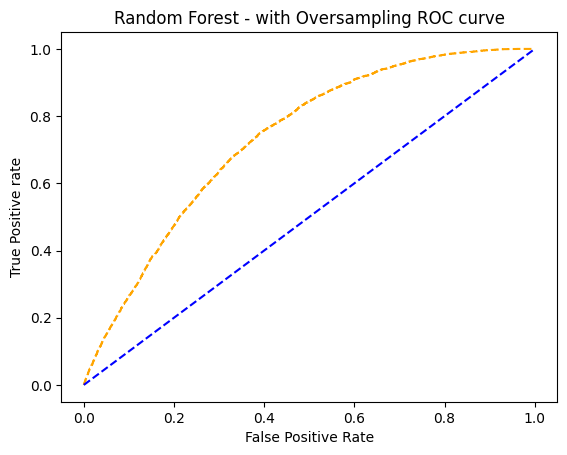

In [31]:
# ROC-AUC Curve
# plot roc curves
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, thresholds = roc_curve(y_test, random_probs, pos_label=1)
plt.plot(fpr, tpr, linestyle='--', color='orange')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
# title
plt.title('Random Forest - with Oversampling ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.savefig('Random Forest - with Oversampling ROC curve',dpi=300)
plt.show()

In [32]:
### Calculate recall_score of the Random Forest model to determine its sensitivity

sensitivity = recall_score(y_test, y_pred, pos_label=1)
print(f"Random Forest Recall Score (Sensitivity): {sensitivity:.4f}")

Random Forest Recall Score (Sensitivity): 0.5791


In [33]:
### Calculate precision_score of the Random Forest

precision = precision_score(y_test, y_pred, pos_label=1)
print(f"Random Forest Precision Score: {precision:.4f}")

Random Forest Precision Score: 0.2251


In [34]:
# Save model
with open("saved_models/random_forest_model_Oversampled.pkl", "wb") as f:
    pickle.dump(rf, f)

#### 4.4.2 XGBoost

In [35]:
from xgboost import XGBClassifier

In [36]:
# Build an XGBoost Model
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=5,  # Adjust based on imbalance
    eval_metric='auc',
    random_state=1
)

In [37]:
start_time = time.time()

In [38]:
# Train the XGBoost model
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [39]:
end_time = time.time()
training_time = end_time - start_time
print(f"XGBoost Training Time: {training_time:.2f} seconds")

XGBoost Training Time: 11.02 seconds


In [40]:
# Predict y given X_test
y_pred_proba = xgb.predict_proba(X_test)[:, 1]

In [41]:
## Determine optimal threshold for XGB
chosen_threshold = find_best_threshold(y_test, y_pred_proba, thresholds=None)
chosen_threshold

0.56

In [42]:
y_pred = (y_pred_proba > chosen_threshold).astype(int)

In [43]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label=1)
auc_score = auc(fpr, tpr)
print("XGBoost - with Oversampling AUC (in %):", auc_score*100)

XGBoost - with Oversampling AUC (in %): 77.04573269630612


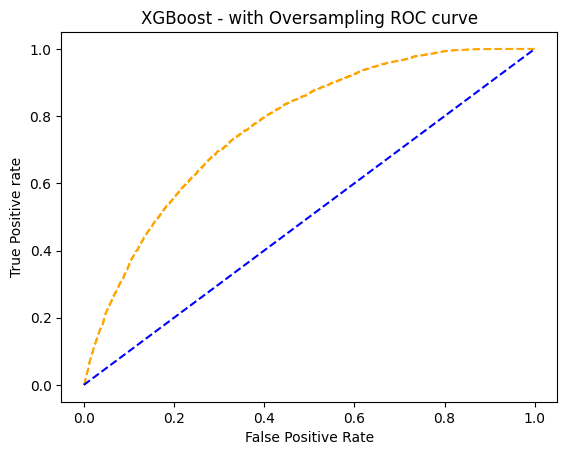

In [44]:
# ROC-AUC Curve
# plot roc curves
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, thresholds = roc_curve(y_test, random_probs, pos_label=1)
plt.plot(fpr, tpr, linestyle='--', color='orange')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
# title
plt.title('XGBoost - with Oversampling ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.savefig('XGBoost - with Oversampling ROC curve',dpi=300)
plt.show()

In [45]:
### Calculate recall_score of the XGBoost model to determine its sensitivity

sensitivity = recall_score(y_test, y_pred, pos_label=1)
print(f"XGBoost Recall Score (Sensitivity): {sensitivity:.4f}")

XGBoost Recall Score (Sensitivity): 0.5166


In [46]:
### Calculate precision_score of the XGBoost Model

precision = precision_score(y_test, y_pred, pos_label=1)
print(f"XGBoost Precision Score: {precision:.4f}")

XGBoost Precision Score: 0.2788


In [47]:
# Save model (JSON is preferred, supports portability)
xgb.save_model("saved_models/xgb_model_Oversampled.json")

#### 4.4.3 Artificial Neural Network (ANN)

In [48]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [49]:
# Compute class weights
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {i: class_weights[i] for i in range(len(classes))}

In [50]:
# Build Functional API ANN
inputs = Input(shape=(X_train_scaled.shape[1],), name='input_layer')
x = Dense(64, activation='relu', name='dense_1')(inputs)
x = Dropout(0.3, name='dropout_1')(x)
x = Dense(32, activation='relu', name='dense_2')(x)
x = Dropout(0.2, name='dropout_2')(x)
outputs = Dense(1, activation='sigmoid', name='output_layer')(x)

In [51]:
# Build an ANN model
model = Model(inputs=inputs, outputs=outputs, name='functional_ann')

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_AUC', patience=3, restore_best_weights=True, mode='max')

In [52]:
start_time = time.time()

In [53]:
# Train the ANN model with timing
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - AUC: 0.6418 - loss: 0.4944 - val_AUC: 0.0000e+00 - val_loss: 1.0805
Epoch 2/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.7413 - loss: 0.4273 - val_AUC: 0.0000e+00 - val_loss: 1.0341
Epoch 3/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.7577 - loss: 0.4161 - val_AUC: 0.0000e+00 - val_loss: 1.0273
Epoch 4/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.7661 - loss: 0.4128 - val_AUC: 0.0000e+00 - val_loss: 0.9938


In [54]:
end_time = time.time()
training_time = end_time - start_time
print(f"ANN Training Time: {training_time:.2f} seconds")

ANN Training Time: 20.54 seconds


In [55]:
# Predict y given X_test_scaled
y_pred_proba = model.predict(X_test_scaled)

1413/1413 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [56]:
## Determine optimal threshold for ANN
chosen_threshold = find_best_threshold(y_test, y_pred_proba, thresholds=None)
chosen_threshold

0.39

In [57]:
y_pred = (y_pred_proba > chosen_threshold).astype(int)

In [58]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba,pos_label=1)
auc_score = auc(fpr, tpr)
print("ANN - with Oversampling AUC (in %):", auc_score*100)

ANN - with Oversampling AUC (in %): 74.92066247109034


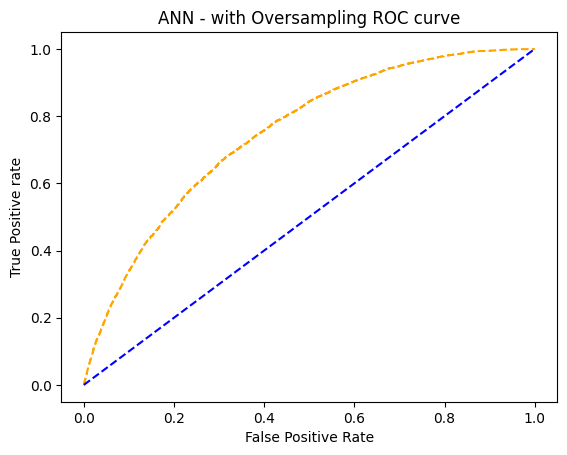

In [59]:
# ROC-AUC Curve
# plot roc curves
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, thresholds = roc_curve(y_test, random_probs, pos_label=1)
plt.plot(fpr, tpr, linestyle='--', color='orange')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
# title
plt.title('ANN - with Oversampling ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.savefig('ANN - with Oversampling ROC curve',dpi=300)
plt.show()

In [60]:
### Calculate recall_score of the ANN model to determine its sensitivity

sensitivity = recall_score(y_test, y_pred, pos_label=1)
print(f"ANN Recall Score (Sensitivity): {sensitivity:.4f}")

ANN Recall Score (Sensitivity): 0.4796


In [61]:
### Calculate precision_score of the ANN model

precision = precision_score(y_test, y_pred, pos_label=1)
print(f"ANN Precision Score {precision:.4f}")

ANN Precision Score 0.2693


In [62]:
# Save ANN
model.save("saved_models/ann_model_Oversampled.keras")

#### 4.4.4 Support Vector Machine (SVM) - Linear SVC

In [63]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

In [64]:
# Define pipeline with scaling + LinearSVC
pipeline = Pipeline([
    ('svc', LinearSVC(C=1.0, loss="squared_hinge", class_weight='balanced', max_iter=10000, random_state=1))
])

In [65]:
start_time = time.time()

In [66]:
# Fit the model
pipeline.fit(X_train_scaled, y_train)

Pipeline(steps=[('svc',
                 LinearSVC(class_weight='balanced', max_iter=10000,
                           random_state=1))])

In [67]:
end_time = time.time()
training_time = end_time - start_time
print(f"SVM Base Model Training Time: {training_time:.2f} seconds")

SVM Base Model Training Time: 14.42 seconds


In [68]:
# Predict y given X_test_scaled
y_pred_proba = pipeline.decision_function(X_test_scaled)

In [69]:
## Determine optimal threshold for SVM
chosen_threshold = find_best_threshold(y_test, y_pred_proba, thresholds=None)
chosen_threshold

0.11

In [70]:
y_pred = (y_pred_proba > chosen_threshold).astype(int)

In [71]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba,pos_label=1)
auc_score = auc(fpr, tpr)
print("SVM - with Oversampling AUC (in %):", auc_score*100)

SVM - with Oversampling AUC (in %): 73.99853394408323


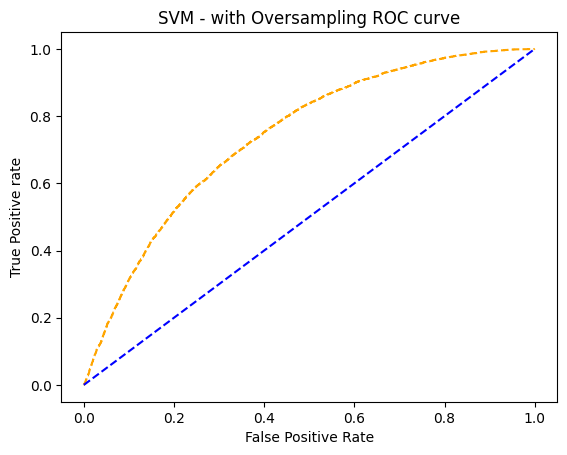

In [72]:
# ROC-AUC Curve
# plot roc curves
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, thresholds = roc_curve(y_test, random_probs, pos_label=1)
plt.plot(fpr, tpr, linestyle='--', color='orange')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
# title
plt.title('SVM - with Oversampling ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.savefig('SVM - with Oversampling ROC curve',dpi=300)
plt.show()

In [73]:
### Calculate recall_score of the baseline model to determine its sensitivity

sensitivity = recall_score(y_test, y_pred, pos_label=1)
print(f"SVM Recall Score (Sensitivity): {sensitivity:.4f}")

SVM Recall Score (Sensitivity): 0.5308


In [74]:
### Calculate precision_score of the SVM model

precision = precision_score(y_test, y_pred, pos_label=1)
print(f"SVM Precision Score {precision:.4f}")

SVM Precision Score 0.2500


In [75]:
# Save model
with open("saved_models/svm_pipeline_Oversampled.pkl", "wb") as f:
    pickle.dump(pipeline, f)

#### 4.4.5 Gradient Boosting Machine (GBM) 

In [76]:
from sklearn.ensemble import GradientBoostingClassifier

In [77]:
# Define GBM model
gbm = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5, 
    subsample=0.8,
    random_state=1
)

In [78]:
gbm.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=5, random_state=1, subsample=0.8)

In [79]:
end_time = time.time()
training_time = end_time - start_time
print(f"GBM Training Time: {training_time:.2f} seconds")

GBM Training Time: 966.95 seconds


In [80]:
# Predict y given X_test
y_pred_proba = gbm.predict_proba(X_test)[:,1]

In [81]:
## Determine optimal threshold for GBM
chosen_threshold = find_best_threshold(y_test, y_pred_proba, thresholds=None)
chosen_threshold

0.2

In [82]:
y_pred = (y_pred_proba > chosen_threshold).astype(int)

In [83]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba,pos_label=1)
auc_score = auc(fpr, tpr)
print("GBM - with Oversampling AUC (in %):", auc_score*100)

GBM - with Oversampling AUC (in %): 76.72152660204769


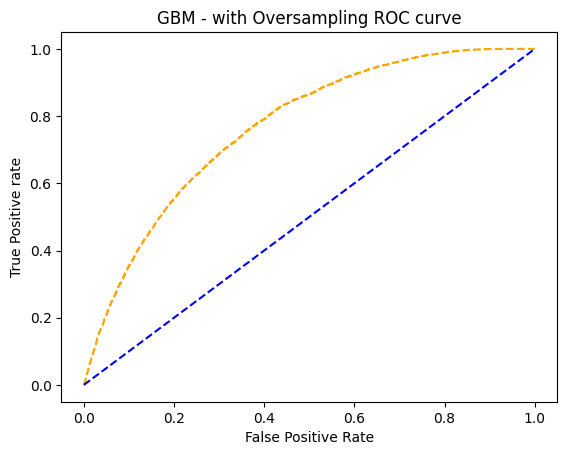

In [84]:
# ROC-AUC Curve
# plot roc curves
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, thresholds = roc_curve(y_test, random_probs, pos_label=1)
plt.plot(fpr, tpr, linestyle='--', color='orange')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
# title
plt.title('GBM - with Oversampling ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.savefig('GBM - with Oversampling ROC curve',dpi=300)
plt.show()

In [85]:
### Calculate recall_score of the baseline model to determine its sensitivity

sensitivity = recall_score(y_test, y_pred, pos_label=1)
print(f"GBM Recall Score (Sensitivity): {sensitivity:.4f}")

GBM Recall Score (Sensitivity): 0.5201


In [86]:
### Calculate precision_score of the SVM model

precision = precision_score(y_test, y_pred, pos_label=1)
print(f"GBM Precision Score {precision:.4f}")

GBM Precision Score 0.2746


In [87]:
# Save model
with open("saved_models/gbm_model_Oversampled.pkl", "wb") as f:
    pickle.dump(gbm, f)